# Introduction

The goal of this project is to explore the data,
perform analysis, create compelling visualizations, and deliver actionable recommendations to stakeholders from a selected database containing clinical trial data from multiple sources.

The selected clinical data source is *COVID-19 Clinical Trials dataset*. This source is only composed of one CVS file. Note: Other options were not accesible at the time of analysis.

To achieve the general goal, 5 business questions have to be answered:

**1. Trial Landscape Overview:** What is the distribution of clinical trials by phase, status, and therapeutic area? How has this
evolved over time?  
**2. Completion Analysis:** Which factors are associated with higher trial completion rates? Are there patterns in trials that get
terminated or withdrawn?  
**3. Enrollment Performance:** What are the trends in patient enrollment across different trial types? Which conditions attract
the most participants?  
**4. Geographic Insights:** How are clinical trials distributed globally? Are there regional specializations in certain therapeutic
areas?  
**5. Duration Analysis:** What is the typical duration of trials by phase and therapeutic area? Which trials take significantly
longer than expected?

Lastly, the information contained in the data source has to fall into SQL tables with the following squeme.

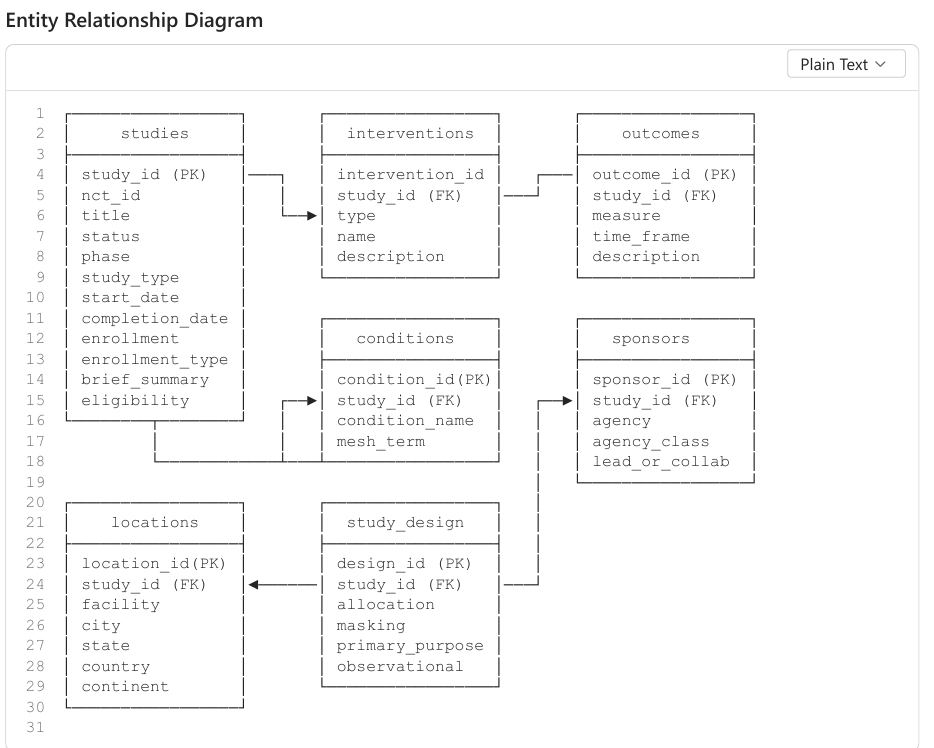

# Exploratory analysis

First, we upload the file

In [158]:
#from google.colab import files

#print("Select the file COVID.csv:")
#uploaded = files.upload()

We take a look at a sample of the table, focusing on the fields we will be using in this exercise.

These fields correspond to those in the fact table (*studies*) and those in two of the dimension tables (*interventions* and *locations*).

I have not included the rest because, given the scope of this exercise, these are the ones needed to answer the questions. However, I recognise that other fields, such as *study design* information, would be worth including in the project.

The reason for not including the *conditions* will be explained in the answer to the third question

In [159]:
import pandas as pd

df = pd.read_csv("/content//COVID.csv")


display(df[['NCT Number', 'Title', 'Acronym', 'Status', 'Phases', 'Study Type', 'Start Date', 'Completion Date', 'Primary Completion Date',
'Enrollment','Age','Gender', 'Interventions', 'Locations']].head(5))


,NCT Number,Title,Acronym,Status,Phases,Study Type,Start Date,Completion Date,Primary Completion Date,Enrollment,Age,Gender,Interventions,Locations
0,NCT04785898,Diagnostic Performance of the ID Now™ COVID-19 Screening Test Versus Simplexa™ COVID-19 Direct Assay,COVID-IDNow,"Active, not recruiting",Not Applicable,Interventional,"November 9, 2020","April 30, 2021","December 22, 2020",1000.0,"18 Years and older (Adult, Older Adult)",All,Diagnostic Test: ID Now™ COVID-19 Screening Test,"Groupe Hospitalier Paris Saint-Joseph, Paris, Ile De France, France"
1,NCT04595136,Study to Evaluate the Efficacy of COVID19-0001-USR in Patients With Mild/or Moderate COVID-19 Infection in Outpatient,COVID-19,Not yet recruiting,Phase 1|Phase 2,Interventional,"November 2, 2020","January 29, 2021","December 15, 2020",60.0,"18 Years and older (Adult, Older Adult)",All,Drug: Drug COVID19-0001-USR|Drug: normal saline,"Cimedical, Barranquilla, Atlantico, Colombia"
2,NCT04395482,Lung CT Scan Analysis of SARS-CoV2 Induced Lung Injury,TAC-COVID19,Recruiting,NaN,Observational,"May 7, 2020","June 15, 2021","June 15, 2021",500.0,"18 Years and older (Adult, Older Adult)",All,Other: Lung CT scan analysis in COVID-19 patients,"Ospedale Papa Giovanni XXIII, Bergamo, Italy|Policlinico San Marco-San Donato group, Bergamo, Italy|Azienda Ospedaliero-Universitaria di Ferrara, Ferrara, Italy|ASST di Lecco Ospedale Alessandro Manzoni, Lecco, Italy|ASST Melegnano-Martesana, Ospedale Santa Maria delle Stelle, Melzo, Italy|ASST Monza, Monza, Italy|AUSL Romagna-Ospedale Infermi di Rimini, Rimini, Italy|Istituto per la Sicurezza Sociale-Ospedale della Repubblica di San Marino, San Marino, San Marino"
3,NCT04416061,The Role of a Private Hospital in Hong Kong Amid COVID-19 Pandemic,COVID-19,"Active, not recruiting",NaN,Observational,"May 25, 2020","August 31, 2020","July 31, 2020",2500.0,"Child, Adult, Older Adult",All,Diagnostic Test: COVID 19 Diagnostic Test,"Hong Kong Sanatorium & Hospital, Hong Kong, Hong Kong"
4,NCT04395924,Maternal-foetal Transmission of SARS-Cov-2,TMF-COVID-19,Recruiting,NaN,Observational,"May 5, 2020",May 2021,May 2021,50.0,18 Years to 48 Years (Adult),Female,"Diagnostic Test: Diagnosis of SARS-Cov2 by RT-PCR and : IgG, Ig M serologies in the amniotoc fluid, the blood cord and the placenta","CHR Orléans, Orléans, France"


## Tables

### SQL Tables creation

We create the SQL tables. Note: Gemini was used to learn this code.

Some changes have been made to the original definitions in these tables:

1- Studies: Fields *enrollment_type*, *brief_summary* and *eligibility_criteria* were deleted as in principle, they could not be extracted from the original file. Maximum and minimum age where merged as age. This is because, although it would be interesting to analyse the age fields numerically, the original field had a very inconsistent format across the records; therefore, given the scope of this exercise, it was not worth constructing them.

2- Locations: Field Continent was deleted as it wasn't included in the source field, it would have taken time to build and didn't provide much relevant information.

3- Interventions: Field *name* was deleted. It was not discernible in the original field.

In [160]:
import sqlite3

# 1. Connection to the database
conn = sqlite3.connect('clinical_trial_data.db')
cur = conn.cursor()

# 2. Table 'studies'
cur.execute("DROP TABLE IF EXISTS studies")  #Not necessary, just in case I wanted to change something in the structure
cur.execute("""
CREATE TABLE IF NOT EXISTS studies (
    study_id INTEGER PRIMARY KEY AUTOINCREMENT,
    nct_id VARCHAR(20) UNIQUE NOT NULL,
    title TEXT,
    acronym VARCHAR(50),
    status VARCHAR(50),
    phase VARCHAR(50),
    study_type VARCHAR(50),
    start_date DATE,
    completion_date DATE,
    primary_completion_date DATE,
    enrollment INTEGER,
    age VARCHAR(20),
    gender VARCHAR(20),
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
    updated_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
)
""")
# 3. Table 'locations'
cur.execute("DROP TABLE IF EXISTS locations") #Not necessary, just in case I wanted to change something in the structure
cur.execute("""
CREATE TABLE IF NOT EXISTS locations (
    location_id INTEGER PRIMARY KEY AUTOINCREMENT,
    study_id INTEGER,
    facility VARCHAR(255),
    city VARCHAR(100),
    state VARCHAR(100),
    country VARCHAR(100),
    FOREIGN KEY (study_id) REFERENCES studies (study_id)
)
""")
#4. Table 'interventions'
cur.execute("DROP TABLE IF EXISTS interventions") #Not necessary, just in case I wanted to change something in the structure
cur.execute("""
CREATE TABLE IF NOT EXISTS interventions (
    intervention_id INTEGER PRIMARY KEY AUTOINCREMENT,
    study_id INTEGER,
    intervention_type VARCHAR(50),
    description TEXT,
    FOREIGN KEY (study_id) REFERENCES studies (study_id)
)
""")

# Indexes
Indexes = [

    "CREATE INDEX IF NOT EXISTS idx_studies_status ON studies (status)",
    "CREATE INDEX IF NOT EXISTS idx_studies_phase ON studies (phase)",
    "CREATE INDEX IF NOT EXISTS idx_studies_start_date ON studies (start_date)",

    "CREATE INDEX IF NOT EXISTS idx_interv_study_id ON interventions (study_id)"
]

for sql in Indexes:
    cur.execute(sql)

conn.commit()

# 4. Save and close
conn.commit()
conn.close()

print("Step completed: The studies, locations and interventions tables have been created.")

Step completed: The studies, locations and interventions tables have been created.


### Data load into the tables.

We load the studies table. In this case, is a direct load. No treatment of NULL was done as I prefer to manage them during the analysis for the fact table. Note: Gemini was used to learn this code.

In [161]:
import sqlite3
import pandas as pd

# 1. Data preparation
df_studies = df[['NCT Number', 'Title', 'Acronym', 'Status', 'Phases',
                 'Study Type', 'Start Date', 'Completion Date',
                 'Primary Completion Date', 'Enrollment', 'Age', 'Gender']].copy()

# Rename the fields
df_studies.columns = [
    'nct_id', 'title', 'acronym', 'status', 'phase',
    'study_type', 'start_date', 'completion_date',
    'primary_completion_date', 'enrollment', 'age', 'gender'
]

# 2. Database upload process
conn = sqlite3.connect('clinical_trial_data.db')
cur = conn.cursor()

try:
    # DELETE existing data to avoid duplicates
    cur.execute("DELETE FROM studies")

    # INSERT the new data
    # Setting index=False is essential to prevent the creation of an “index” column in SQL
    df_studies.to_sql('studies', conn, if_exists='append', index=False)

    # Save changes
    conn.commit()
    print(f"Upload complete: {len(df_studies)} records inserted into 'studies'.")

except Exception as e:
    print(f"There was an error while loading the data: {e}")
    conn.rollback()

Upload complete: 5783 records inserted into 'studies'.


We load the interventions table. Nulls were removed. Original records were splited in different rows when the symbol '|' was encountered. Also, the record were splited when the symbol ':' was encountered to create the corresponding fields. Note: Gemini was used to learn this code.

In [162]:
# after 'studies' and before closing the connection.
mapping_df = pd.read_sql("SELECT study_id, nct_id FROM studies", conn)
id_map = dict(zip(mapping_df['nct_id'], mapping_df['study_id']))

# PROCESSING
df_int = df[['NCT Number', 'Interventions']].copy().dropna(subset=['Interventions'])
df_int['Interventions'] = df_int['Interventions'].str.split('|')
df_int = df_int.explode('Interventions')

# Field split
int_split = df_int['Interventions'].str.split(':', n=1, expand=True)

df_load_int = pd.DataFrame({
    'study_id': df_int['NCT Number'].map(id_map),
    'intervention_type': int_split[0].str.strip(),
    'description': int_split[1].str.strip()
})

# Loading
try:
    cur = conn.cursor()
    cur.execute("DELETE FROM interventions")
    df_load_int.to_sql('interventions', conn, if_exists='append', index=False)
    conn.commit()
    print(f"Interventions loaded: {len(df_load_int)} records.")
except Exception as e:
    print(f"Error loading interventions: {e}")
    conn.rollback()

Interventions loaded: 8165 records.


We load the locations table. Nulls were removed. Original records were splited in different rows when the symbol '|' was encountered. Also, the record were splited when the symbol ',' was encountered to create the corresponding fields. We start by selecting the records from the end of the list corresponding to the country. Given the inconsistency of the records, this ensures that, at the very least, the country field is correct. There are some records with incorrect names, but these will be dealt with later in the queries. Note: Gemini was used to learn this code.

In [163]:
# 1. Preparation
df_loc = df.copy()
df_loc = df_loc.dropna(subset=['Locations'])
df_loc['Locations'] = df_loc['Locations'].str.split('|')
df_loc = df_loc.explode('Locations')

temp_list = df_loc['Locations'].str.split(',')

df_loc['country'] = temp_list.str[-1].str.strip()
df_loc['city']    = temp_list.str[-2].str.strip()
df_loc['state']   = temp_list.str[-3].str.strip()
df_loc['facility'] = temp_list.str[0].str.strip()

# 2. Processing
df_load_loc = pd.DataFrame({
    'study_id': df_loc['NCT Number'].map(id_map),
    'facility': df_loc['facility'],
    'city': df_loc['city'],
    'state': df_loc['state'],
    'country': df_loc['country']
})

# 3. Loading and close
try:
    cur = conn.cursor()

    cur.execute("DELETE FROM locations")

    df_load_loc.to_sql('locations', conn, if_exists='append', index=False)
    conn.commit()

    print(f"Succes: {len(df_load_loc)} records loaded in 'locations'.")

except Exception as e:
    print(f"Error in loading: {e}")
    conn.rollback()

finally:
    # We close the connection permanently
    conn.close()
    print("Database connection closed.")

Succes: 24115 records loaded in 'locations'.
Database connection closed.


# Business Questions

In [164]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect('clinical_trial_data.db')
pd.set_option('display.max_colwidth', None)

## **1. Trial Landscape Overview:** What is the distribution of clinical trials by phase, status, and therapeutic area? How has this evolved over time?

For this particular dataset, the therapeutic area is not applicable. Note: Gemini was only used for helping with the graphs.

Few cases dated from 1998 onwards were seen, probably related to other SARS viruses. For the scope of this exercises, we only focus on recent years (outlier treatment).

As we can see in the graphs, almost all studies started on 2020 (peak of the pandemic) followed by 2021.

Note: I would have liked to add another layer showing the analysis by month, but I decided against it to save time

### Distribution by phase

We can see many studies in Phase 2 (and Phase 3). This may seem counterintuitive, but it is worth noting that in the rush to find a treatment for the virus in 2020, existing medicines were tested (such as remdesivir or dexamethasone). Additionally, combined phases were a key characteristic of COVID trials during the pandemic.



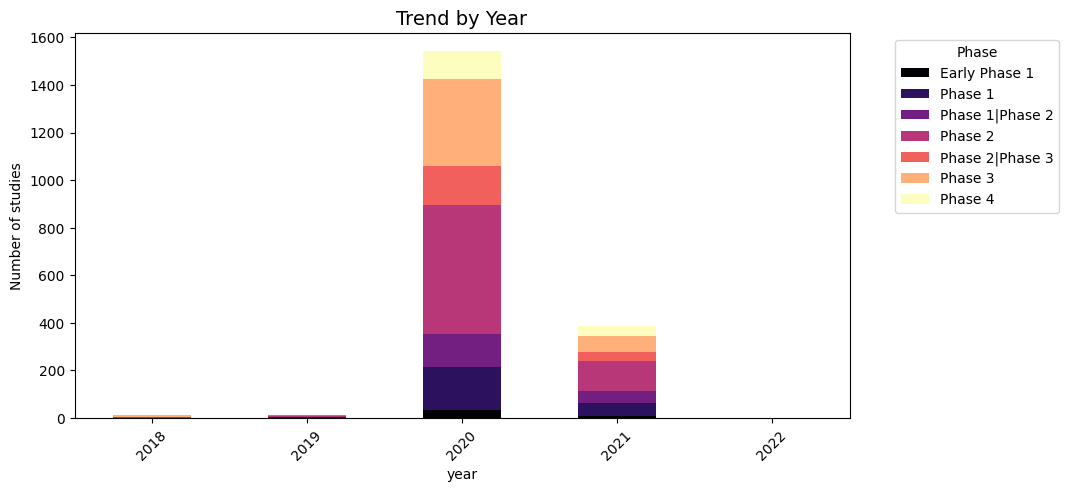

In [165]:

query_phase = """
SELECT
    SUBSTR(start_date, -4) as year,
    phase,
    count(*) as total
FROM studies
WHERE start_date IS NOT NULL
  AND year > '2017'
  AND phase IS NOT NULL AND phase<>'Not Applicable'
GROUP BY year, phase
"""

df_phase = pd.read_sql_query(query_phase, conn)
df_phase_pivot = df_phase.pivot(index='year', columns='phase', values='total').fillna(0)

# Gráfico
df_phase_pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='magma')
plt.title('Trend by Year', fontsize=14)
plt.ylabel('Number of studies')
plt.legend(title='Phase', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

### Distribution by status

We can see a huge number of studies that were in *Recruiting* status during 2020, while many others were already *Completed* within that same year. This reflects the global effort to fast-track clinical research. We can also notice *Terminated* and *Withdrawn* studies, which shows that trials were stopped when they did not meet the necessary requirements for security reasons.

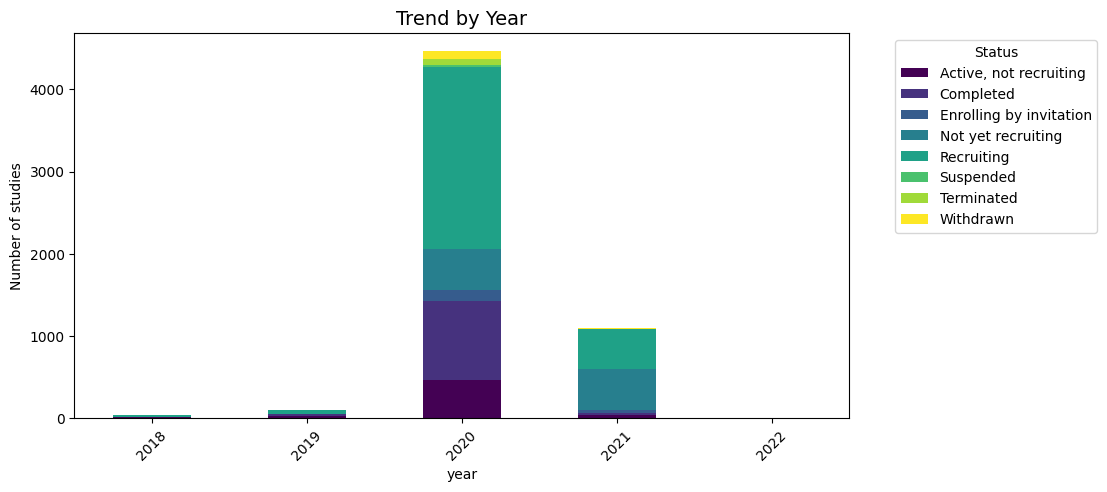

In [166]:
query_status = """
SELECT
    SUBSTR(start_date, -4) as year,
    status,
    count(*) as total
FROM studies
WHERE start_date IS NOT NULL
  AND year > '2017'
GROUP BY year, status
"""

df_status = pd.read_sql_query(query_status, conn)
df_status_pivot = df_status.pivot(index='year', columns='status', values='total').fillna(0)

# Gráfico
df_status_pivot.plot(kind='bar', stacked=True, figsize=(10, 5), colormap='viridis')
plt.title('Trend by Year', fontsize=14)
plt.ylabel('Number of studies')
plt.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

## **2. Completion Analysis:** Which factors are associated with higher trial completion rates? Are there patterns in trials that get terminated or withdrawn?  

After investigating, it seems that the study type is the key factor with higher trial completion rate. More precisely, the categories that fall in the Expanded Acces types are the key for non completion of the trials. Interventional or observational study types (which are the majority) mean that the trial will complete.

It is worth to add that Not completed trials also have NULL values in the start date and enrollment fields...

Note: Gemini was only used to construct the graphic, not the query.

As for the second question, I could not find a clear pattern in trials that get terminated or withdrawn on time, but the most plausible reason are the security reasons during the rush for finding a treatment in 2020/21 mentioned on the answer for the first business question.

In [167]:
import pandas as pd
query_comp= """
WITH CTE AS (
SELECT
    *, CASE WHEN COMPLETION_DATE IS NOT NULL THEN 1 ELSE 0 END AS COMPLETED,
    COUNT(*) OVER (PARTITION BY CASE WHEN COMPLETION_DATE IS NOT NULL THEN 1 ELSE 0 END) AS COUNT_COMPLETED_TOTAL
FROM studies )
SELECT study_type, COMPLETED, COUNT(*),COUNT_COMPLETED_TOTAL
FROM CTE GROUP BY study_type, COMPLETED, COUNT_COMPLETED_TOTAL ORDER BY COMPLETED, STUDY_TYPE
"""
df_comp = pd.read_sql_query(query_comp, conn)
#df_comp

import plotly.express as px

# 1. Prepare data
df_viz = df_comp.copy()

# 2. Calculate totals to include them in the legend
# We get the sum of COUNT(*) for each status (0 and 1)
status_totals = df_viz.groupby('COMPLETED')['COUNT(*)'].sum()

# 3. Map status to a string that includes the total count
# This will force the legend to show: "Completed (Total: XXX)"
df_viz['Status'] = df_viz['COMPLETED'].map({
    1: f"Completed (Total: {int(status_totals.get(1, 0))})",
    0: f"Not Completed (Total: {int(status_totals.get(0, 0))})"
})

# 4. Calculate relative percentage for the bar scaling
total_per_type = df_viz.groupby('study_type')['COUNT(*)'].transform('sum')
df_viz['Percentage'] = (df_viz['COUNT(*)'] / total_per_type) * 100

# 5. Create the chart
fig = px.bar(
    df_viz,
    y="study_type",
    x="Percentage",
    color="Status", # Using the new Status column with totals
    orientation='h',
    title="<b>Study Completion Rate by Type with Global Totals</b>",
    labels={"Percentage": "Percentage (%)", "study_type": "Study Type"},
    # Map colors to the new strings
    color_discrete_map={
        f"Completed (Total: {int(status_totals.get(1, 0))})": '#27ae60',
        f"Not Completed (Total: {int(status_totals.get(0, 0))})": '#e74c3c'
    },
    text=df_viz['Percentage'].apply(lambda x: f'{x:.1f}%'),
    hover_data={'COUNT(*)': True, 'Percentage': ':.1f%'}
)

# 6. Aesthetic adjustments
fig.update_layout(
    height=600,
    xaxis_title="Completion Percentage",
    yaxis_title="Study Category",
    legend_title="Status & Global Totals",
    margin=dict(l=300),
    barmode='stack'
)

fig.show()

## **3. Enrollment Performance:** What are the trends in patient enrollment across different trial types? Which conditions attract the most participants?  

To answer the first question, we check the enrollment by study type. While there are more studies of interventional type, it seems that the observational type attracts more enrollment on average.

In [168]:
import pandas as pd
query_enr1= """
WITH CTE AS (
SELECT
    *, COUNT(*) OVER (PARTITION BY study_type) AS Total_studies
FROM studies WHERE ENROLLMENT is not null)
SELECT study_type, ROUND(AVG(Enrollment)) AS Enrollment_AVG, Total_studies
FROM CTE group by study_type

"""
df_enr1 = pd.read_sql_query(query_enr1, conn)
df_enr1

,study_type,Enrollment_AVG,Total_studies
0,Interventional,8195.0,3322
1,Observational,32178.0,2427


Now we check the average enrollment by intervention_type. It seems that the Behavioral type have the most enrollment by average.


In [169]:
import pandas as pd
query_enr2= """
SELECT intervention_type, ROUND(AVG(Enrollment)) AS Enrollment_AVG
FROM INTERVENTIONS
inner JOIN studies ON INTERVENTIONS.study_id = studies.study_id
GROUP BY intervention_type ORDER BY Enrollment_AVG DESC

"""
df_enr2 = pd.read_sql_query(query_enr2, conn)
df_enr2

,intervention_type,Enrollment_AVG
0,Behavioral,41855.0
1,Device,29937.0
2,Other,21561.0
3,Diagnostic Test,3791.0
4,Biological,3138.0
5,Dietary Supplement,1574.0
6,Drug,1518.0
7,Procedure,996.0
8,Genetic,603.0
9,Combination Product,439.0


Finally, we check if there is a pattern in the enrollment by gender across interventional types. Enrollment is mostly mixed across all types. However, there are some interesting cases, such as more women in Drug studies or more men in Dietary Supplement studies.

Note: Gemini was only used to construct the graphic, not the query.

It would have been interesting to carry out the same study using age as a variable, but as I mentioned earlier, given the scope of this exercise, I did not think it was worth cleaning up the field.

In [170]:
import pandas as pd
query_enr3= """
WITH CTE AS (
SELECT intervention_type, gender, Enrollment, AVG(Enrollment) OVER (PARTITION BY intervention_type, gender) AS Enrollment_by_gender,
AVG(Enrollment) OVER (PARTITION BY intervention_type) AS Enrollment_by_intervention_type
FROM INTERVENTIONS
inner JOIN studies ON INTERVENTIONS.study_id = studies.study_id
WHERE gender IS NOT NULL)
SELECT intervention_type, gender, round(Enrollment_by_gender), round(Enrollment_by_intervention_type)
FROM CTE group by intervention_type, gender ORDER BY Enrollment_by_intervention_type DESC, gender

"""
df_enr3 = pd.read_sql_query(query_enr3, conn)
df_enr3

import plotly.express as px

# 1. Create a copy and rename the SQL-generated columns for a cleaner chart legend
df_plot = df_enr3.copy()
df_plot.columns = ['Intervention Type', 'Gender', 'Avg_Enrollment_Gender', 'Avg_Enrollment_Total']

# 2. Create the grouped bar chart
fig = px.bar(
    df_plot,
    x='Intervention Type',
    y='Avg_Enrollment_Gender',
    color='Gender',
    barmode='group', # Key parameter to place bars side-by-side
    title="<b>Average Study Enrollment by Intervention and Gender</b>",
    labels={
        'Avg_Enrollment_Gender': 'Average Enrollment',
        'Intervention Type': 'Intervention Type',
        'Gender': 'Eligible Gender'
    },
    # Map specific colors to each gender category (Swapped Green/Blue)
    color_discrete_map={
        'All': '#2ecc71',    # Green for mixed studies
        'Female': '#9b59b6', # Purple for female-only studies
        'Male': '#3498db'    # Blue for male-only studies
    },
    # Add the total intervention enrollment to the hover tooltip
    hover_data={'Avg_Enrollment_Total': True}
)

# 3. Aesthetic and layout adjustments
fig.update_layout(
    height=600,
    xaxis_title="Intervention Type",
    yaxis_title="Average Enrollment (Patients)",
    legend_title="Eligible Gender",
    template='plotly_white', # Clean white background, report-ready
    hovermode="x unified"    # Unified hover to compare all three genders at once
)

fig.show()

To answer the second question, it was also necessary to clean up and organise the original *conditions* field (for example merging Covid19, covid19, COVID...). Nevertheless, as with the age, given the scope of this exercise, I did not think it was worth it.

In [171]:
df_cond = df.copy()
df_cond = df_cond.dropna(subset=['Conditions'])
df_cond['Conditions'] = df_cond['Conditions'].str.split('|')
df_cond = df_cond.explode('Conditions')

display(df_cond[['Rank', 'Conditions']])

,Rank,Conditions
0,1,Covid19
1,2,SARS-CoV-2 Infection
2,3,covid19
3,4,COVID
4,5,Maternal Fetal Infection Transmission
...,...,...
5781,5782,Anxiety Disorder of Childhood
5781,5782,Depressive Symptoms
5781,5782,Behavior Problem of Childhood and Adolescence
5781,5782,Mental Health Disorder


## **4. Geographic Insights:** How are clinical trials distributed globally? Are there regional specializations in certain therapeutic areas?  

The next graphic shows how the clinical trials are distributed globally. We can see that most of the studies in this dataset are from the US.

Note: Gemini was only used to construct the graphic, not the query.

Second question is not applicable in this dataset as all trials are covid related.

In [172]:
query_geo = """
SELECT
    CASE
        WHEN country = 'Russian Federation' THEN 'Russia'
        WHEN country = 'Islamic Republic of' THEN 'Iran'
        WHEN country = 'Republic of' AND city = 'Korea' THEN 'South Korea'
        WHEN country = 'Republic of' AND city = 'Moldova' THEN 'Moldova'
        WHEN country = 'The Democratic Republic of the' THEN 'Congo'
        WHEN country = "Lao People's Democratic Republic" THEN 'Laos'
        WHEN country = 'Dominican Republic' THEN 'Dominican Rep.'
        ELSE country
    END AS country_clean,
    count(DISTINCT studies.study_id) as number_of_trials
FROM LOCATIONS
INNER JOIN studies ON LOCATIONS.study_id = studies.study_id
GROUP BY country_clean
ORDER BY number_of_trials DESC
"""

df_geo = pd.read_sql_query(query_geo, conn)

import plotly.express as px

fig = px.choropleth(df_geo,
                    locations="country_clean",
                    locationmode='country names',
                    color="number_of_trials",
                    hover_name="country_clean",
                    color_continuous_scale="YlOrRd",
                    title='<b>Global Clinical Data Distribution</b>')


fig.update_layout(
    height=800,
    margin={"r":10,"t":80,"l":10,"b":10},
    geo=dict(
        showframe=False,
        showcoastlines=True,
        projection_type='equirectangular',
        lataxis_range=[-60, 90]
    )
)

fig.show()

## **5. Duration Analysis:** What is the typical duration of trials by phase and therapeutic area? Which trials take significantly longer than expected?

The following graph shows the expected and actual duration of trials by phase (therapeutic area is not applicable here).

Generally, phases take between 8 and 11 months longer than expected on average.

Note: Gemini was used to create the graph and, in this case, was also used to construct the dates subctracts as it seems SQLite does not support text to date or number commands that I am used to do on other platforms.



In [173]:
import pandas as pd


query_dur= """
WITH CTE AS (
SELECT
    PHASE,
    Start_Date,
    Completion_Date,
    Primary_Completion_Date,

    CAST(JULIANDAY(
        SUBSTR(Completion_Date, -4) || '-' ||
        CASE SUBSTR(Completion_Date, 1, 3)
            WHEN 'Jan' THEN '01' WHEN 'Feb' THEN '02' WHEN 'Mar' THEN '03' WHEN 'Apr' THEN '04' WHEN 'May' THEN '05' WHEN 'Jun' THEN '06'
            WHEN 'Jul' THEN '07' WHEN 'Aug' THEN '08' WHEN 'Sep' THEN '09' WHEN 'Oct' THEN '10' WHEN 'Nov' THEN '11' WHEN 'Dec' THEN '12'
        END || '-' ||
        CASE WHEN INSTR(Completion_Date, ',') > 0
             THEN PRINTF('%02d', CAST(TRIM(SUBSTR(Completion_Date, INSTR(Completion_Date, ' ') + 1, 2), ',') AS INTEGER))
             ELSE '01' END
    ) - JULIANDAY(
        SUBSTR(Start_Date, -4) || '-' ||
        CASE SUBSTR(Start_Date, 1, 3)
            WHEN 'Jan' THEN '01' WHEN 'Feb' THEN '02' WHEN 'Mar' THEN '03' WHEN 'Apr' THEN '04' WHEN 'May' THEN '05' WHEN 'Jun' THEN '06'
            WHEN 'Jul' THEN '07' WHEN 'Aug' THEN '08' WHEN 'Sep' THEN '09' WHEN 'Oct' THEN '10' WHEN 'Nov' THEN '11' WHEN 'Dec' THEN '12'
        END || '-' ||
        CASE WHEN INSTR(Start_Date, ',') > 0
             THEN PRINTF('%02d', CAST(TRIM(SUBSTR(Start_Date, INSTR(Start_Date, ' ') + 1, 2), ',') AS INTEGER))
             ELSE '01' END
    ) AS INTEGER) AS Completion_start,

    CAST(JULIANDAY(
        SUBSTR(Completion_Date, -4) || '-' ||
        CASE SUBSTR(Completion_Date, 1, 3)
            WHEN 'Jan' THEN '01' WHEN 'Feb' THEN '02' WHEN 'Mar' THEN '03' WHEN 'Apr' THEN '04' WHEN 'May' THEN '05' WHEN 'Jun' THEN '06'
            WHEN 'Jul' THEN '07' WHEN 'Aug' THEN '08' WHEN 'Sep' THEN '09' WHEN 'Oct' THEN '10' WHEN 'Nov' THEN '11' WHEN 'Dec' THEN '12'
        END || '-' ||
        CASE WHEN INSTR(Completion_Date, ',') > 0
             THEN PRINTF('%02d', CAST(TRIM(SUBSTR(Completion_Date, INSTR(Completion_Date, ' ') + 1, 2), ',') AS INTEGER))
             ELSE '01' END
    ) - JULIANDAY(
        SUBSTR(Primary_Completion_Date, -4) || '-' ||
        CASE SUBSTR(Primary_Completion_Date, 1, 3)
            WHEN 'Jan' THEN '01' WHEN 'Feb' THEN '02' WHEN 'Mar' THEN '03' WHEN 'Apr' THEN '04' WHEN 'May' THEN '05' WHEN 'Jun' THEN '06'
            WHEN 'Jul' THEN '07' WHEN 'Aug' THEN '08' WHEN 'Sep' THEN '09' WHEN 'Oct' THEN '10' WHEN 'Nov' THEN '11' WHEN 'Dec' THEN '12'
        END || '-' ||
        CASE WHEN INSTR(Primary_Completion_Date, ',') > 0
             THEN PRINTF('%02d', CAST(TRIM(SUBSTR(Primary_Completion_Date, INSTR(Primary_Completion_Date, ' ') + 1, 2), ',') AS INTEGER))
             ELSE '01' END
    ) AS INTEGER) AS completion_primary

FROM studies where Start_Date IS NOT NULL
and phase IS NOT NULL AND phase<>'Not Applicable'
and Completion_Date is not null
and Primary_Completion_Date is not null)
SELECT PHASE, AVG(Completion_start) Completion_start, AVG(completion_primary) AS completion_primary
FROM CTE GROUP BY PHASE ORDER BY PHASE

"""
df_dur = pd.read_sql_query(query_dur, conn)
df_dur


import plotly.graph_objects as go
import pandas as pd

# 1. Prepare data and calculate the numerical gap
df_dur_viz = df_dur.copy()
df_dur_viz = df_dur_viz.rename(columns={
    'Completion_start': 'Actual',
    'completion_primary': 'Expected'
})

# Calculate the difference (gap)
df_dur_viz['Gap'] = df_dur_viz['Actual'] - df_dur_viz['Expected']

# Define the logical chronological order for the phases
phase_order = [
    'Early Phase 1',
    'Phase 1',
    'Phase 1|Phase 2',
    'Phase 2',
    'Phase 2|Phase 3',
    'Phase 3',
    'Phase 4'
]

# 2. Create the Figure
fig = go.Figure()

# Loop through each phase to draw connectors and centered Gap labels
for i, phase in enumerate(phase_order):
    mask = df_dur_viz['PHASE'] == phase
    if not mask.any(): continue
    row = df_dur_viz[mask].iloc[0]

    # Draw the gray connector line
    fig.add_trace(go.Scatter(
        x=[row['Expected'], row['Actual']],
        y=[row['PHASE'], row['PHASE']],
        mode='lines',
        line=dict(color='#d3d3d3', width=2),
        showlegend=False,
        hoverinfo='skip'
    ))

    # Add the "Gap" text centered ABOVE the line
    fig.add_trace(go.Scatter(
        x=[row['Expected'] + (row['Gap'] / 2)],
        y=[row['PHASE']],
        mode='text',
        text=[f"+{int(row['Gap'])}d"],
        textposition='top center',
        # Removed 'stroke' and 'strokewidth' to fix the ValueError
        textfont=dict(color='#555555', size=11),
        showlegend=False,
        hoverinfo='skip'
    ))

# Add 'Expected' points with values BELOW the marker
fig.add_trace(go.Scatter(
    x=df_dur_viz['Expected'],
    y=df_dur_viz['PHASE'],
    mode='markers+text',
    name='Expected Duration',
    text=df_dur_viz['Expected'].apply(lambda x: f"{int(x)}"),
    textposition="bottom center",
    textfont=dict(size=10, color='#2980b9'),
    marker=dict(
        color='#a6cee3',
        size=14,
        line=dict(color='white', width=1)
    ),
    hovertemplate="<b>%{y}</b><br>Expected: %{x} days<extra></extra>"
))

# Add 'Actual' points with values BELOW the marker
fig.add_trace(go.Scatter(
    x=df_dur_viz['Actual'],
    y=df_dur_viz['PHASE'],
    mode='markers+text',
    name='Actual Duration',
    text=df_dur_viz['Actual'].apply(lambda x: f"{int(x)}"),
    textposition="bottom center",
    textfont=dict(size=10, color='#c0392b'),
    marker=dict(
        color='#e31a1c',
        size=14,
        line=dict(color='white', width=1)
    ),
    hovertemplate="<b>%{y}</b><br>Actual: %{x} days<br>Gap: %{customdata} days<extra></extra>",
    customdata=df_dur_viz['Gap']
))

# 3. Layout configuration
fig.update_layout(
    title="<b>Detailed Trial Duration Gap Analysis (Days)</b>",
    xaxis_title="Days",
    yaxis_title="Phase",
    yaxis=dict(categoryorder='array', categoryarray=phase_order),
    template='plotly_white',
    height=700,
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1
    ),
    margin=dict(l=150, r=50, t=120, b=80),
    plot_bgcolor='#fafafa'
)

fig.show()